# K-Means Clustering

## Importing the libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [4]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

## Using the elbow method to find the optimal number of clusters

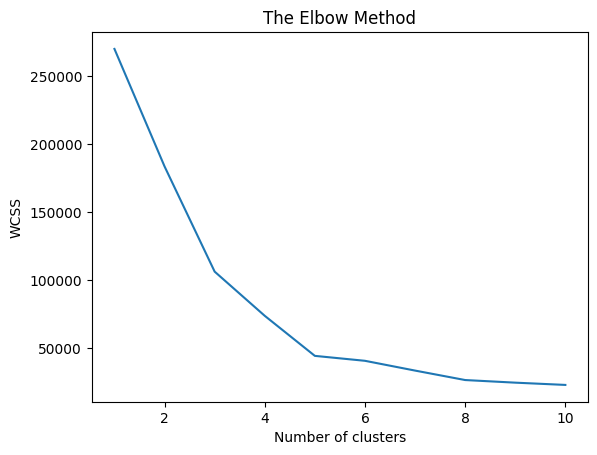

In [5]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) #k-means++: Pick the first center randomly, then prefer points that are far away from existing centers
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [18]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [19]:
print(kmeans.inertia_) #Inertia = sum of squared distances to nearest centroid
mse = kmeans.inertia_ / len(X)  #Average squared distance per data point
print("MSE:", mse)

from sklearn.metrics import silhouette_score
score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)

44448.45544793371
MSE: 222.24227723966854
Silhouette Score: 0.553931997444648


## Visualising the clusters

In [ ]:
#print(y_kmeans)
#print(X[y_kmeans==0])# boolean indexing 

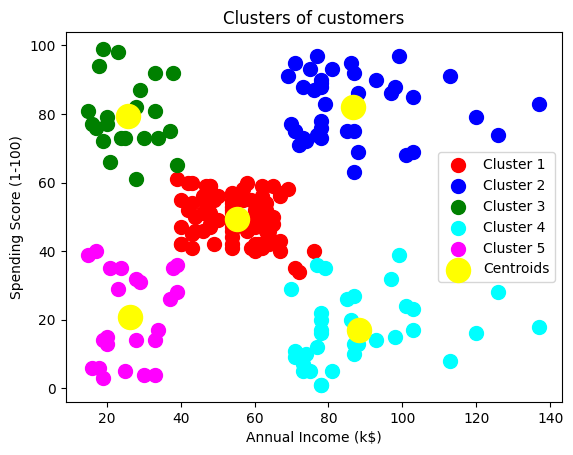

In [7]:
plt.scatter(X[y_kmeans == 0, 0], # X-coordinator : feature 0 of cluster 0 data
            X[y_kmeans == 0, 1], # Y-coordinator : feature 1 of cluster 0 data
            s = 100, #pixel size
            c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Silhouette values, organized by cluster.
## Wide to the right (~0.8–1.0) → very good cluster
## Narrow / near 0 → overlapping cluster
## Extending left (<0) → misclassified points

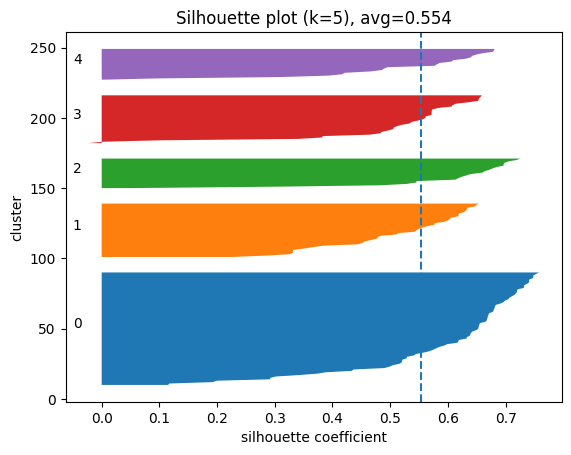

In [20]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt

labels = kmeans.labels_
k = len(np.unique(labels))

sample_vals = silhouette_samples(X, labels)
avg = silhouette_score(X, labels)

y_lower = 10
for i in range(k):
    vals_i = sample_vals[labels == i]
    vals_i.sort()
    size_i = vals_i.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i)
    plt.text(-0.05, (y_lower + y_upper) / 2, str(i))

    y_lower = y_upper + 10  # gap between clusters

plt.axvline(avg, linestyle="--")
plt.xlabel("silhouette coefficient")
plt.ylabel("cluster")
plt.title(f"Silhouette plot (k={k}), avg={avg:.3f}")
plt.show()